# Maize abiotic-stress phenotyping: single-plant PlantCV photo-studio pipeline (JoVE 67619)

**Paper:** *Imaging and Analysis for Quantifying Maize (Zea mays) Abiotic Stress Phenotypes*,
Journal of Visualized Experiments (JoVE), DOI [10.3791/67619](https://doi.org/10.3791/67619) (PMID 40228008).

**Code:** author repository [`danforthcenter/photo-maize-paper`](https://github.com/danforthcenter/photo-maize-paper),
pinned commit `d470cf2c4e2f73cd187f5982751b94ba277fe4b1`, script `plantcv-analysis/workflow.py`.

**Scope (executed partial demonstration):** run the authors' single-plant RGB PlantCV
photo-studio pipeline — color-card correction, Lab a/b dual-channel segmentation, ROI
filtering, then size / height-boundary / color analyses — on **one sample maize image**
(`Pot_14`, 2024-07-19 09:21:12) from the authors' Zenodo record
[13379801](https://zenodo.org/records/13379801), and compare the outputs with the
authors' published example results for the same image in the same repository.

**Not covered:** the camera/photo-studio hardware protocol, batch processing of the full
experiment, and the R statistical analysis (`data-analysis/`); the JoVE article full text
is subscription-gated, so all pipeline parameters here come from the pinned author code.
This notebook does not verify dataset-level results of the paper — it is a hands-on
single-example reproduction.

*日本語: このノートブックは JoVE 67619（トウモロコシのアバイオティックストレス表現型計測）の
PlantCV 写真スタジオ・パイプラインを、著者公開コード（コミット `d470cf2c` 固定）と
Zenodo 13379801 のサンプル画像 1 枚（Pot_14）で再現します。色補正・二値化・ROI 解析から
サイズ・高さ境界・色形質を算出し、著者の公開出力と比較します。ハードウェア手順・バッチ処理・
R による統計解析は対象外です。*

**Execution status:** validated end-to-end on a fresh Google Colab **CPU** runtime
(2026-10-09). Recommended runtime: **CPU** (no GPU is needed; the pipeline contains no
neural-network or tensor operations).

## Runtime and Run all

Select **Runtime → Change runtime type → CPU** (the default). Then **Runtime → Run all**.

- Expected wall time on a fresh CPU runtime: ≈ 5–10 minutes total (dominated by the
  ≈ 69 MB Zenodo download and image I/O; the analysis steps themselves are seconds each).
- Downloads: `raw-images.zip` (69,291,607 bytes, MD5-checked) from Zenodo plus a few MB of
  pinned author reference files from GitHub. Nothing is required from Google Drive, and no
  login, token, or private API is used.
- *日本語: ランタイムは CPU を推奨（GPU 不要）。すべてのセルを上から順に実行します。
  合計 5〜10 分、ダウンロードは約 69 MB + 数 MB です。*

## 1. Environment setup

We install PlantCV, the open-source plant phenotyping image-analysis library (MPL-2.0)
used by the authors. The authors' repository does not pin a PlantCV version; their
`workflow.py` uses the PlantCV 4.x API (`transform.detect_color_card`,
`transform.affine_color_correction`, `threshold.dual_channels`, `roi.filter`,
`analyze.size/bound_horizontal/color`), so we pin the current 4.x release and report the
actually installed version.

*日本語: 著者が使用した PlantCV 4.x API に合わせて PlantCV をインストールし、実行時に
実際のバージョンを表示します。*

In [ ]:
%pip install -q plantcv==4.11.3

import importlib.metadata, os
import matplotlib, numpy as np, cv2
from plantcv import plantcv as pcv
print("plantcv   :", importlib.metadata.version("plantcv"))
print("opencv    :", cv2.__version__)
print("numpy     :", np.__version__)
print("matplotlib:", matplotlib.__version__)
pcv.params.debug = None  # we display images explicitly below instead of debug plots
os.makedirs("/content/outputs", exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 kB 4.8 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.6 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.8 MB/s eta 0:00:00


  Installing build dependencies ... done


  Getting requirements to build wheel ... done


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 33.5/33.5 MB 184.7 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 33.5/33.5 MB 184.7 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 33.5/33.5 MB 184.7 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 18.9 MB/s eta 0:00:00


plantcv   : 4.11.3
opencv    : 4.11.0
numpy     : 2.1.3
matplotlib: 3.10.0


## 2. Input data acquisition (Zenodo record 13379801)

The raw images live in the authors' Zenodo deposit *“JoVE Raspberry Pi Imaging of Maize”*
(record 10.5281/**13379801**, deposited 2024-08-27). Following the Zenodo read-only API
pattern, we first query the record's file **metadata** (names, sizes, checksums, and the
content URL the record itself returns) — we never construct a download URL by hand.

*日本語: まず Zenodo の公開記録 API でファイル一覧（サイズ・チェックサム・URL）を取得します。*

In [ ]:
import json, urllib.request

ZENODO_RECORD = "13379801"
with urllib.request.urlopen(f"https://zenodo.org/api/records/{ZENODO_RECORD}", timeout=60) as r:
    record = json.load(r)
print("title      :", record["metadata"]["title"])
print("doi        :", record["doi"])
for f in record["files"]:
    print(f"{f['size']:>12,} bytes  md5={f['checksum']}  {f['key']}")

raw = next(f for f in record["files"] if f["key"] == "raw-images.zip")
RAW_URL, RAW_SIZE, RAW_MD5 = raw["links"]["self"], raw["size"], raw["checksum"]
print("\nselected   :", raw["key"], RAW_SIZE, "bytes,", RAW_MD5)

title      : JoVE Raspberry Pi Imaging of Maize
doi        : 10.5281/zenodo.13379801
1,521,222,637 bytes  md5=md5:db98bba7f2d304171cd748db7b4a4721  raspberrypi-image-capture.img.gz
  69,291,607 bytes  md5=md5:994f839c0b6b7d662fc715a2e865711f  raw-images.zip

selected   : raw-images.zip 69291607 bytes, md5:994f839c0b6b7d662fc715a2e865711f


### Download and checksum verification

We download `raw-images.zip` (≈ 69 MB — the whole archive must be fetched; it is the
smallest Zenodo file containing the raw images; the 1.5 GB Raspberry Pi OS image is not
needed), then verify the exact byte count and MD5 checksum recorded by Zenodo before
using the data.

*日本語: raw-images.zip（約 69 MB）をダウンロードし、Zenodo が記録したバイト数と MD5 を
検証してから使用します（不要な 1.5 GB の OS イメージは取得しません）。*

In [ ]:
import hashlib, os, urllib.request

ARCHIVE = "/content/raw-images.zip"
if not (os.path.exists(ARCHIVE) and os.path.getsize(ARCHIVE) == RAW_SIZE):
    req = urllib.request.Request(RAW_URL)
    with urllib.request.urlopen(req, timeout=600) as resp, open(ARCHIVE, "wb") as fh:
        total = int(resp.headers.get("Content-Length", 0))
        done = 0
        while True:
            chunk = resp.read(1 << 20)
            if not chunk:
                break
            fh.write(chunk)
            done += len(chunk)
            if done % (16 << 20) < (1 << 20):
                print(f"  {done/1e6:7.1f} / {total/1e6:.1f} MB", flush=True)
print("downloaded :", os.path.getsize(ARCHIVE), "bytes")

md5 = hashlib.md5()
with open(ARCHIVE, "rb") as fh:
    for chunk in iter(lambda: fh.read(1 << 20), b""):
        md5.update(chunk)
assert os.path.getsize(ARCHIVE) == RAW_SIZE, "size mismatch vs Zenodo metadata"
assert f"md5:{md5.hexdigest()}" == RAW_MD5, "MD5 mismatch vs Zenodo metadata"
print("checksum   : OK", RAW_MD5)

     16.8 / 69.3 MB


     33.6 / 69.3 MB


     50.3 / 69.3 MB


     67.1 / 69.3 MB


downloaded : 69291607 bytes
checksum   : OK md5:994f839c0b6b7d662fc715a2e865711f


### Select and extract the one sample image

The archive holds the experiment's raw images; we list its contents and extract only the
single sample used throughout this notebook: `Pot_14`, imaged **2024-07-19 09:21:12**
(the exact image whose analysis outputs the authors published in the repository). We
verify it parses as a real JPEG.

*日本語: ZIP 内の一覧から解析対象の 1 枚（Pot_14, 2024-07-19 09:21:12）だけを選んで
展開し、JPEG として解析可能か確認します。*

In [ ]:
import zipfile, cv2

with zipfile.ZipFile(ARCHIVE) as zf:
    names = zf.namelist()
    print(f"zip contains {len(names)} entries")
    # Skip macOS resource-fork entries (__MACOSX/._...) and keep only real JPEGs
    hits = sorted(n for n in names
                  if not n.startswith("__MACOSX")
                  and n.lower().endswith(".jpg")
                  and "Pot_14" in os.path.basename(n)
                  and "2024-07-19T09-21-12" in n)
    assert len(hits) == 1, f"expected exactly one matching sample image, got {hits}"
    SAMPLE_ZIP_PATH = hits[0]
    print("sample     :", SAMPLE_ZIP_PATH)
    zf.extract(SAMPLE_ZIP_PATH, "/content/")
    SAMPLE = os.path.join("/content/", SAMPLE_ZIP_PATH)

img_bgr = cv2.imread(SAMPLE, cv2.IMREAD_COLOR)
assert img_bgr is not None, "sample does not parse as an image"
print("extracted  :", SAMPLE, img_bgr.shape, "(H, W, BGR)")

zip contains 34 entries
sample     : raw-images/Array-Pot_14_2024-07-19T09-21-12.jpg
extracted  : /content/raw-images/Array-Pot_14_2024-07-19T09-21-12.jpg (3456, 4608, 3) (H, W, BGR)


## 3. Input preview

Before any analysis, we display the actual raw sample with its provenance: a photo-studio
maize plant (pot visible at the bottom, color card in frame) captured by the low-cost
single-board-computer setup described in the paper. Dimensions are printed from the data
itself.

*日本語: 解析前に入力画像そのものを表示します（撮影日時・ファイル名は実データから取得）。*

raw sample : Array-Pot_14_2024-07-19T09-21-12.jpg (3456, 4608, 3) uint8 RGB


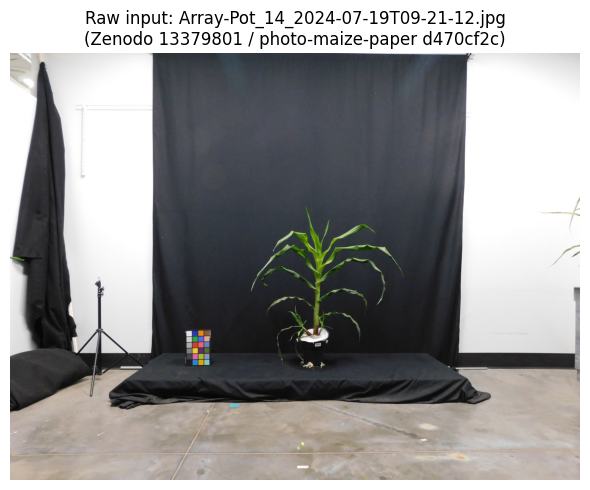

In [ ]:
import matplotlib.pyplot as plt

raw_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print("raw sample :", os.path.basename(SAMPLE), raw_rgb.shape, "uint8 RGB")
fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(raw_rgb)
ax.set_title(f"Raw input: {os.path.basename(SAMPLE)}\n(Zenodo 13379801 / photo-maize-paper d470cf2c)")
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/01_raw_input.png", dpi=110, bbox_inches="tight")
plt.show()

## 4. Authors' reference outputs for this exact image

The repository pins the authors' saved analysis images and numeric results for
`Array-Pot_14_2024-07-19T09-21-12.jpg`. We fetch them from the pinned commit's raw URLs
and verify each byte stream against the GitHub **git blob SHA-1** and size recorded in the
pinned tree — this is an integrity check of the reference material, not a re-download of
the input. The two `_shape`/`_shape-bound` JPGs are the authors' saved outputs for this
image; `results-photo-studio.json` holds their measured trait values.

*日本語: 同一画像に対する著者の公開解析結果（shape・shape-bound 画像と results JSON）を
固定コミットから取得し、Git blob SHA-1 とサイズで完全性を検証します。*

In [ ]:
import hashlib, urllib.request

PINNED_COMMIT = "d470cf2c4e2f73cd187f5982751b94ba277fe4b1"
BASE = f"https://raw.githubusercontent.com/danforthcenter/photo-maize-paper/{PINNED_COMMIT}/plantcv-analysis/"
REF_FILES = {  # path -> (git blob sha1, expected bytes) from the pinned GitHub tree
    "Array-Pot_14_2024-07-19T09-21-12.jpg_shape.jpg":      ("21d2b5838a5338e1513e306dd366ba6c664761a2", 1314599),
    "Array-Pot_14_2024-07-19T09-21-12.jpg_shape-bound.jpg": ("eb6e0596a4b9bf08facbeb1e15d47221477ad84a", 1241369),
    "results-photo-studio.json":                            ("f6dc32bafe1aef915ac30b3fbde76fc8653daa72", 18692375),
    "test.csv":                                             ("8ad945fc34c5a993dba03be4a15164d459e2eca1", 52904),
}

def blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

os.makedirs("/content/author_ref", exist_ok=True)
for name, (want_sha, want_size) in REF_FILES.items():
    with urllib.request.urlopen(BASE + name, timeout=300) as r:
        data = r.read()
    assert len(data) == want_size and blob_sha1(data) == want_sha, f"integrity check failed: {name}"
    with open(f"/content/author_ref/{name}", "wb") as fh:
        fh.write(data)
    print(f"verified   : {name}  {len(data):,} bytes  blob sha OK")

verified   : Array-Pot_14_2024-07-19T09-21-12.jpg_shape.jpg  1,314,599 bytes  blob sha OK
verified   : Array-Pot_14_2024-07-19T09-21-12.jpg_shape-bound.jpg  1,241,369 bytes  blob sha OK


verified   : results-photo-studio.json  18,692,375 bytes  blob sha OK
verified   : test.csv  52,904 bytes  blob sha OK


### Reference images (authors' saved outputs — clearly labeled)

Display the authors' saved `..._shape.jpg` and `..._shape-bound.jpg` for the sample image.
These are **author reference outputs** (from the pinned repository), not results produced
by this notebook; we compare our own outputs against them in section 6.

*日本語: 著者の保存済み解析画像を表示します（本ノートブックの出力ではなく参照資料です）。*

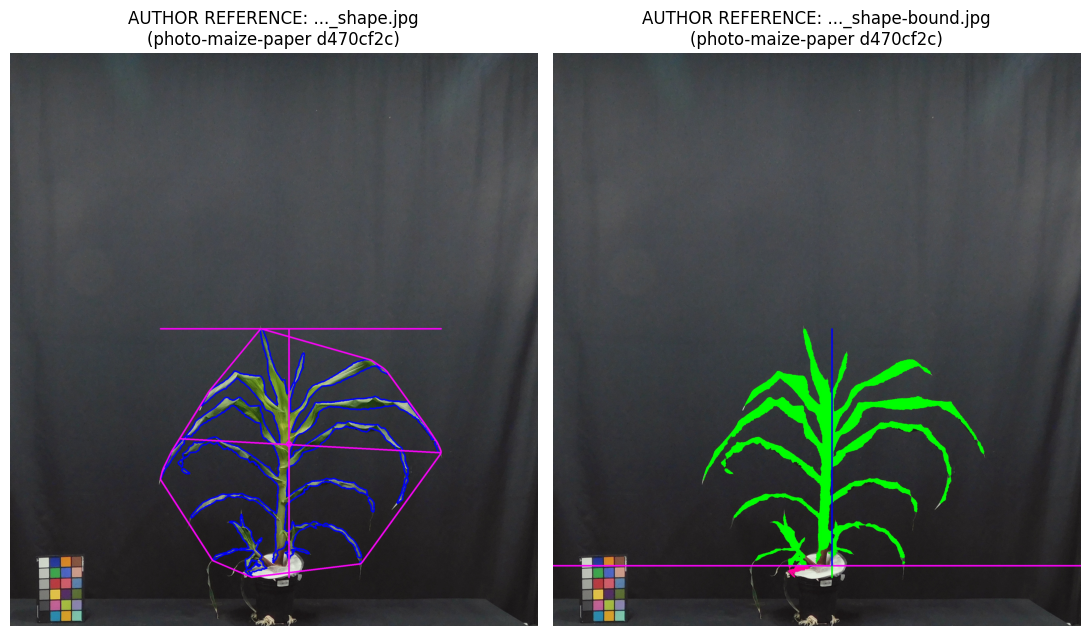

reference shapes: (2500, 2300, 3) (2500, 2300, 3)


In [ ]:
os.makedirs("/content/outputs", exist_ok=True)
ref_shape = cv2.imread("/content/author_ref/Array-Pot_14_2024-07-19T09-21-12.jpg_shape.jpg")
ref_bound = cv2.imread("/content/author_ref/Array-Pot_14_2024-07-19T09-21-12.jpg_shape-bound.jpg")
fig, axes = plt.subplots(1, 2, figsize=(11, 7))
axes[0].imshow(cv2.cvtColor(ref_shape, cv2.COLOR_BGR2RGB))
axes[0].set_title("AUTHOR REFERENCE: ..._shape.jpg\n(photo-maize-paper d470cf2c)")
axes[1].imshow(cv2.cvtColor(ref_bound, cv2.COLOR_BGR2RGB))
axes[1].set_title("AUTHOR REFERENCE: ..._shape-bound.jpg\n(photo-maize-paper d470cf2c)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/02_author_reference.png", dpi=110, bbox_inches="tight")
plt.show()
print("reference shapes:", ref_shape.shape, ref_bound.shape)

## 5. Reproduce the pipeline (workflow.py, pinned commit d470cf2c)

Every step below mirrors `plantcv-analysis/workflow.py` line by line, with the authors'
parameter values unchanged. The only adaptation: instead of the
`plantcv.parallel.workflow_inputs()` CLI wrapper, each step is a readable cell, and we
show intermediate images explicitly instead of using `pcv.params.debug`.

*日本語: 以下の各ステップは著者の `workflow.py` と同じ順序・同じパラメータ値での再現です
（CLI ラッパーを可読なセルに展開し、中間画像を明示表示する点のみ変更）。*

### Step 1 — Read the image (`workflow.py:18`)

`pcv.readimage` loads the file in native RGB order (PlantCV convention: red channel
first). The filename is echoed by the library itself.

*日本語: `pcv.readimage` で RGB 順に画像を読み込みます。*

In [ ]:
img, path, filename = pcv.readimage(filename=SAMPLE, mode="rgb")
print("read:", path, filename, img.shape, img.dtype)

read: /content/raw-images Array-Pot_14_2024-07-19T09-21-12.jpg (3456, 4608, 3) uint8


### Step 2 — Crop to the photo-studio region of interest (`workflow.py:32`)

The authors crop `x=1300, y=50, h=2500, w=2300` to remove studio background and frame the
plant plus color card. This matches the notebook values the authors instruct you to keep
identical between the notebook and `workflow.py`.

*日本語: 著者指定の切り出し（x=1300, y=50, h=2500, w=2300）でスタジオ背景を除きます。*

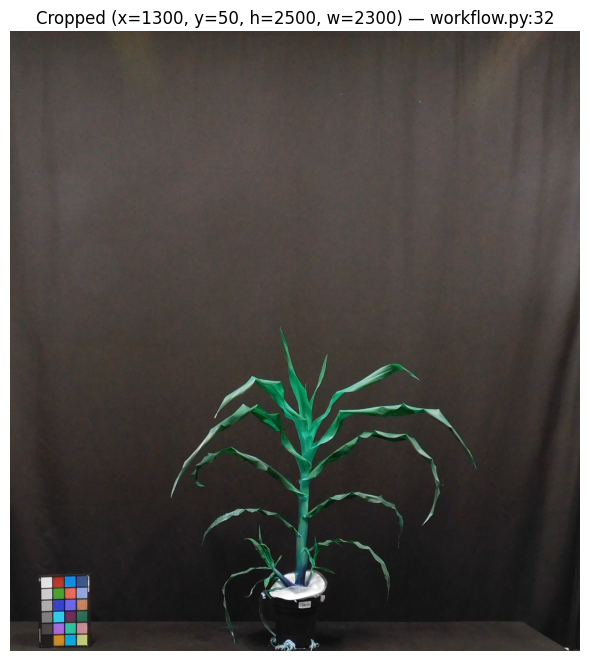

In [ ]:
crop_img = pcv.crop(img=img, x=1300, y=50, h=2500, w=2300)
fig, ax = plt.subplots(figsize=(6, 7))
ax.imshow(crop_img)
ax.set_title("Cropped (x=1300, y=50, h=2500, w=2300) — workflow.py:32")
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/03_cropped.png", dpi=110, bbox_inches="tight")
plt.show()

### Step 3 — Rotate (identity) and detect the color card (`workflow.py:41,53`)

The authors rotate with 0° (kept for faithfulness), then
`pcv.transform.detect_color_card` finds the in-frame color card chips
(`radius=10, adaptive_method=1, block_size=101`). We visualize the detected chip mask and
assert the card was found — without it, color correction cannot proceed.

*日本語: 0° 回転（忠実性のため維持）の後、カラーカードのチップを自動検出します。
検出マスクを可視化し、検出成功を確認します。*

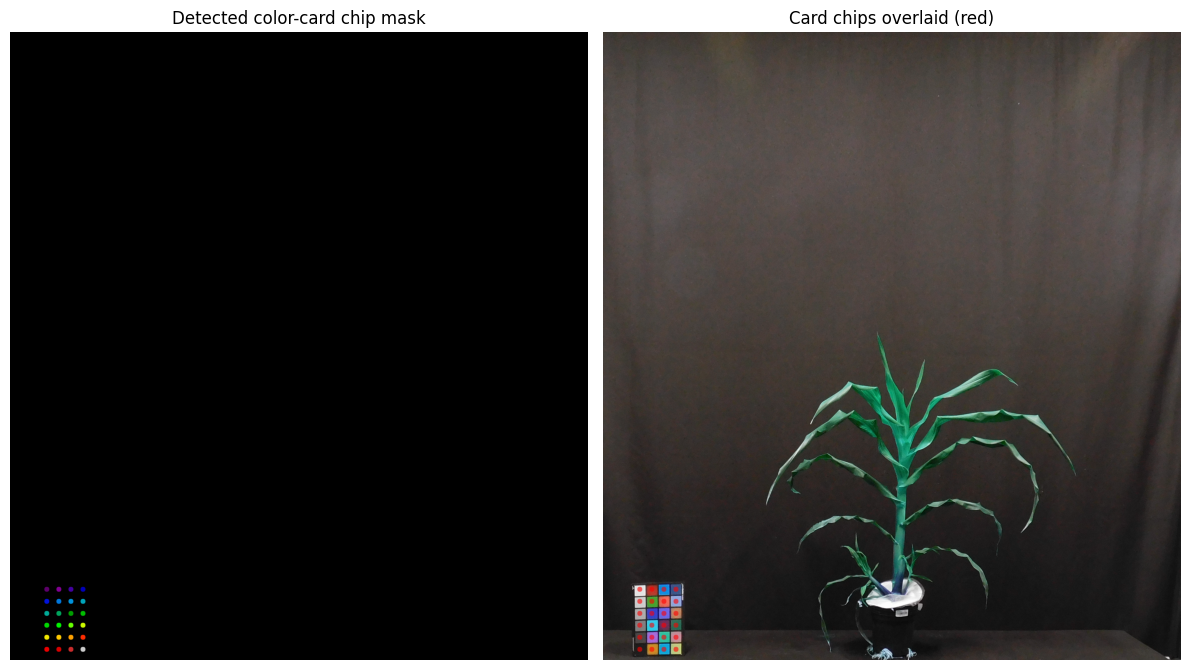

labeled chips: 240


In [ ]:
rotate_img = pcv.transform.rotate(crop_img, 0, False)
card_mask = pcv.transform.detect_color_card(rgb_img=crop_img, radius=10,
                                            adaptive_method=1, block_size=101)
assert card_mask is not None and card_mask.max() > 0, "color card not detected"
overlay = crop_img.copy()
overlay[card_mask > 0] = (0.4 * overlay[card_mask > 0] + 0.6 * np.array([255, 0, 0])).astype(np.uint8)
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
axes[0].imshow(card_mask, cmap="nipy_spectral")
axes[0].set_title("Detected color-card chip mask")
axes[1].imshow(overlay)
axes[1].set_title("Card chips overlaid (red)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/04_color_card.png", dpi=110, bbox_inches="tight")
plt.show()
print("labeled chips:", int(card_mask.max()))

### Step 4 — Color-correct to the standard card (`workflow.py:65-79`)

Read average RGB per detected chip (`get_color_matrix`), build the standard target matrix
(`std_color_matrix(pos=3)` — a standard 24-pip card layout), and apply the authors'
affine color correction so intensities are comparable across the experiment.

*日本語: 検出チップの平均 RGB から行列を作り、標準カード（pos=3）へアフィン色補正します。*

color-corrected: (2500, 2300, 3) uint8 range 6.0 - 243.0


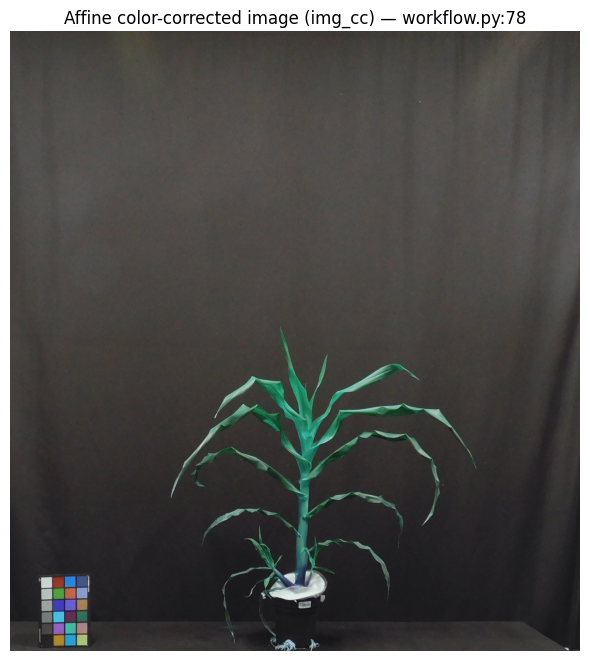

In [ ]:
headers, card_matrix = pcv.transform.get_color_matrix(rgb_img=rotate_img, mask=card_mask)
std_color_matrix = pcv.transform.std_color_matrix(pos=3)
img_cc = pcv.transform.affine_color_correction(rgb_img=rotate_img,
                                               source_matrix=card_matrix,
                                               target_matrix=std_color_matrix)
print("color-corrected:", img_cc.shape, img_cc.dtype, "range",
      float(img_cc.min()), "-", float(img_cc.max()))
fig, ax = plt.subplots(figsize=(6, 7))
ax.imshow(img_cc)
ax.set_title("Affine color-corrected image (img_cc) — workflow.py:78")
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/05_color_corrected.png", dpi=110, bbox_inches="tight")
plt.show()

### Step 5 — Dual-channel (Lab a/b) threshold (`workflow.py:92`)

Plant segmentation uses `pcv.threshold.dual_channels` on the corrected image in CIELAB
space: the a\* (green–red) vs b\* (blue–yellow) plane is split by the authors' line through
(80, 80)–(125, 138), keeping plant pixels (green-ish, `above=True`).

*日本語: 補正画像の CIELAB a\*/b\* 平面で著者の直線分割 [(80,80)–(125,138)] により
植物画素を二値化します。*

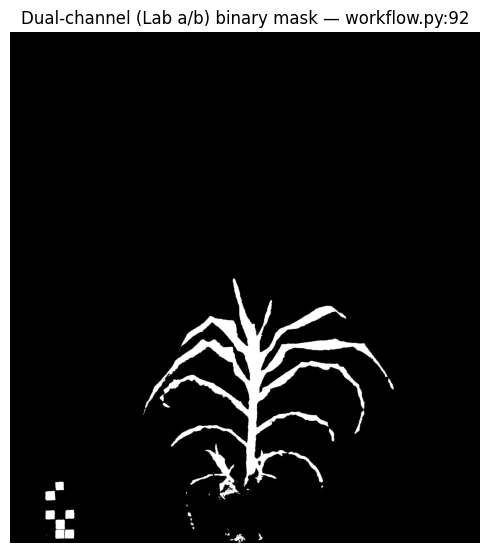

plant pixels: 210782


In [ ]:
dual_thresh = pcv.threshold.dual_channels(rgb_img=img_cc, x_channel="a", y_channel="b",
                                          points=[(80, 80), (125, 138)], above=True)
fig, ax = plt.subplots(figsize=(5, 6))
ax.imshow(dual_thresh, cmap="gray")
ax.set_title("Dual-channel (Lab a/b) binary mask — workflow.py:92")
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/06_dual_threshold.png", dpi=110, bbox_inches="tight")
plt.show()
print("plant pixels:", int((dual_thresh > 0).sum()))

### Step 6 — Mask cleanup: fill specks and close holes (`workflow.py:103,114`)

Small non-plant objects (soil, stray pixels) below 50 px are removed with `pcv.fill`, and
`pcv.closing` fills small holes inside leaves — the authors' exact noise-reduction order.

*日本語: 50 px 未満の小物体を除去し、`closing` で葉内の小さな穴を埋めます。*

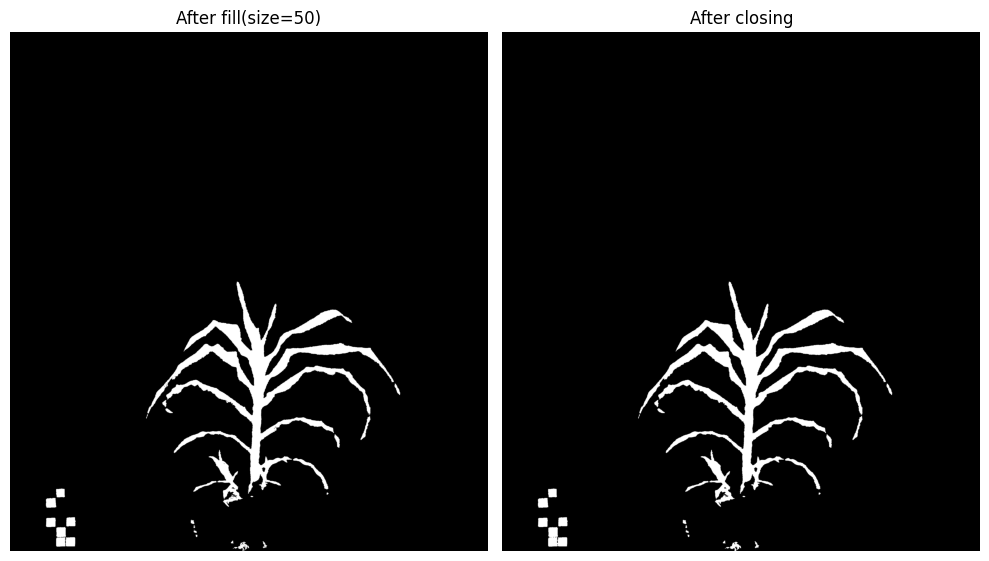

plant pixels: 211282


In [ ]:
mask_fill = pcv.fill(bin_img=dual_thresh, size=50)
mask_fill_holes = pcv.closing(gray_img=mask_fill)
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(mask_fill, cmap="gray"); axes[0].set_title("After fill(size=50)")
axes[1].imshow(mask_fill_holes, cmap="gray"); axes[1].set_title("After closing")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/07_mask_cleanup.png", dpi=110, bbox_inches="tight")
plt.show()
print("plant pixels:", int((mask_fill_holes > 0).sum()))

### Step 7 — ROI filter (`workflow.py:128,142`)

The authors keep only plant material inside the rectangle `x=500, y=900, h=1300, w=1400`
of the corrected image (`roi_type='partial'` keeps objects partially inside), excluding
any residual color card or pot fragments.

*日本語: 著者指定の ROI（x=500, y=900, h=1300, w=1400）内の植物のみを partial フィルタで
残します。*

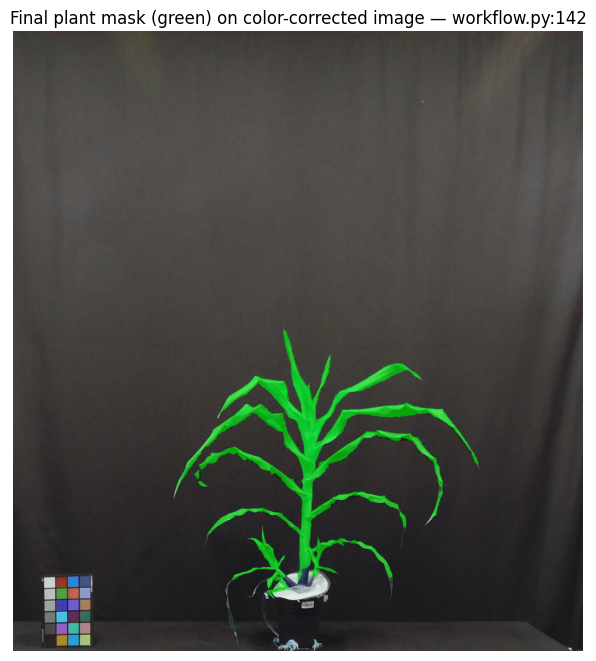

labeled objects: 255 | plant pixels: 195355


In [ ]:
roi1 = pcv.roi.rectangle(img=img_cc, x=500, y=900, h=1300, w=1400)
roi_mask = pcv.roi.filter(mask=mask_fill_holes, roi=roi1, roi_type="partial")
roi_overlay = img_cc.copy()
roi_overlay[roi_mask > 0] = (0.45 * roi_overlay[roi_mask > 0]
                             + 0.55 * np.array([0, 255, 0])).astype(np.uint8)
fig, ax = plt.subplots(figsize=(6, 7))
ax.imshow(roi_overlay)
ax.set_title("Final plant mask (green) on color-corrected image — workflow.py:142")
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/08_roi_mask.png", dpi=110, bbox_inches="tight")
plt.show()
print("labeled objects:", int(roi_mask.max()), "| plant pixels:", int((roi_mask > 0).sum()))

### Step 8 — Size analysis (`workflow.py:156`)

`pcv.analyze.size` measures object traits (area, perimeter, width, height, hull
properties, …) for the labeled mask and stores them in PlantCV's global `Outputs`
collector; the returned image shows the pseudo-colored object.

*日本語: `pcv.analyze.size` で面積・周囲長・幅・高さなどのサイズ形質を計測します。*

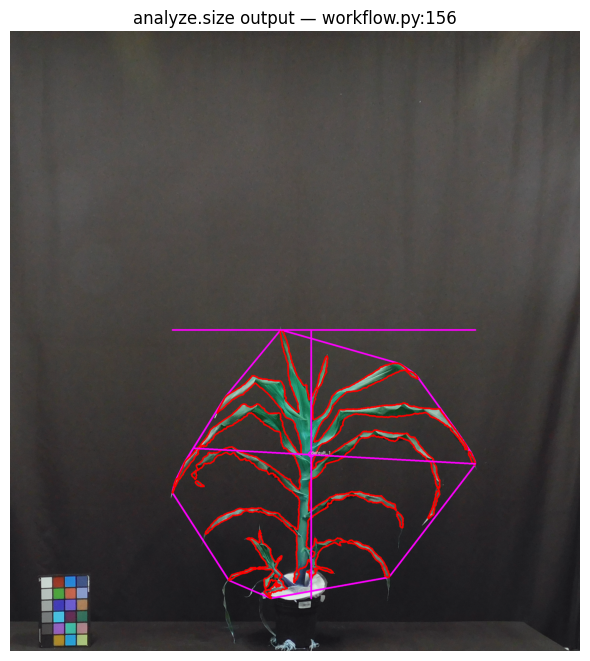

collected trait groups: ['area', 'center_of_mass', 'convex_hull_area', 'convex_hull_vertices', 'ellipse_angle', 'ellipse_center', 'ellipse_eccentricity', 'ellipse_major_axis'] ...


In [ ]:
shape_image = pcv.analyze.size(img=img_cc, labeled_mask=roi_mask, label="default")
fig, ax = plt.subplots(figsize=(6, 7))
ax.imshow(shape_image)
ax.set_title("analyze.size output — workflow.py:156")
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/09_shape.png", dpi=110, bbox_inches="tight")
plt.show()
all_obs = {t: v for _lab, tr in pcv.outputs.observations.items() for t, v in tr.items()}
print("collected trait groups:", sorted(all_obs.keys())[:8], "...")

### Step 9 — Height from the pot top (`workflow.py:171`)

`pcv.analyze.bound_horizontal` measures the plant relative to a horizontal boundary line
at `line_position=2275` — the row the authors identified as the **top of the pot** —
reporting height above/below that line. This is the paper's plant-height trait.

*日本語: 鉢の上端の行（line_position=2275）を基準に、植物の高さ境界形質を計測します。*

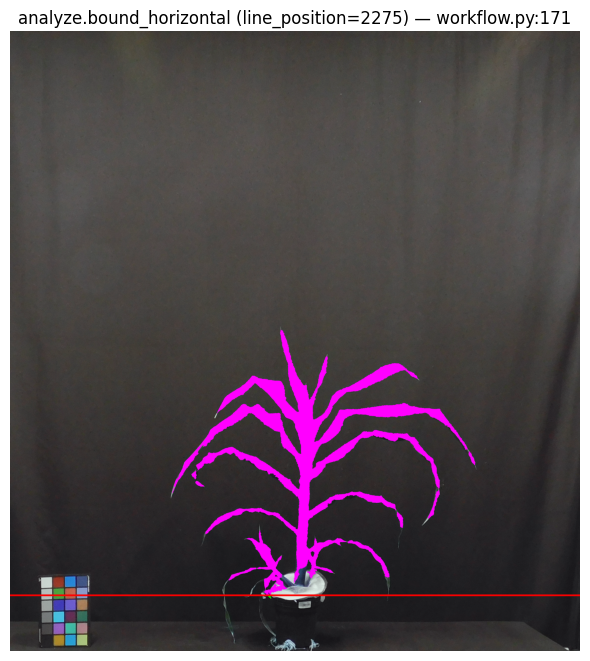

In [ ]:
shape_bound_image = pcv.analyze.bound_horizontal(img=img_cc, labeled_mask=roi_mask,
                                                 line_position=2275, label="default")
fig, ax = plt.subplots(figsize=(6, 7))
ax.imshow(shape_bound_image)
ax.set_title("analyze.bound_horizontal (line_position=2275) — workflow.py:171")
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/10_shape_bound.png", dpi=110, bbox_inches="tight")
plt.show()

### Step 10 — Color analysis (`workflow.py:187`)

`pcv.analyze.color` extracts per-channel histograms in all color spaces (RGB, LAB, HSV)
for the masked plant — the paper's color trait family. In PlantCV 4.x the returned chart
is an Altair figure, so we render it with `display()` instead of `imshow`.

*日本語: `pcv.analyze.color` でマスク領域の全カラースペースのヒストグラム（色形質）を
抽出します。PlantCV 4.x では戻り値が Altair チャートのため `display()` で表示します。*

In [ ]:
color_histogram = pcv.analyze.color(rgb_img=img_cc, labeled_mask=roi_mask,
                                    colorspaces="all", label="default")
display(color_histogram)
print("analyze.color returned:", type(color_histogram).__name__)

alt.FacetChart(...)

analyze.color returned: FacetChart


### Save results (`workflow.py:193`)

`pcv.outputs.save_results` writes every collected measurement to JSON, mirroring the
authors' `results-photo-studio.json` format. PlantCV groups observations by label
(color-chip metadata under `default`, plant traits under `default_1` — exactly the label
structure of the authors' file), so we merge all labels into one trait dictionary and
print the single-value traits.

*日本語: `save_results` で全測定値を JSON に保存します（著者ファイルと同じ
default / default_1 ラベル構造）。全ラベルを統合した形質辞書を作り、単一値形質を表で
表示します。*

In [ ]:
import pandas as pd

os.makedirs("/content/outputs", exist_ok=True)
pcv.outputs.save_results(filename="/content/outputs/results_notebook.json")
obs = {t: v for _lab, tr in pcv.outputs.observations.items() for t, v in tr.items()}
rows = []
for trait, entry in sorted(obs.items()):
    if entry["datatype"] in ("singlevalue", "scalar") or not isinstance(entry["value"], list):
        rows.append({"trait": trait, "value": entry["value"], "datatype": entry["datatype"]})
single = pd.DataFrame(rows)
print(f"{len(single)} single-value traits recorded for sample {os.path.basename(SAMPLE)}")
display(single.head(40))

31 single-value traits recorded for sample Array-Pot_14_2024-07-19T09-21-12.jpg


,trait,value,datatype
0,area,195355.0,<class 'int'>
1,area_above_reference,195252,<class 'int'>
2,area_below_reference,114,<class 'int'>
3,center_of_mass,"(1215.5326712907272, 1706.9522459112898)",<class 'tuple'>
4,convex_hull_area,879609.0,<class 'int'>
5,convex_hull_vertices,31,<class 'int'>
6,ellipse_angle,74.819901,<class 'float'>
7,ellipse_center,"(1243.33251953125, 1772.1346435546875)",<class 'tuple'>
8,ellipse_eccentricity,0.597275,<class 'float'>
9,ellipse_major_axis,994.24176,<class 'int'>


## 6. Comparison with the authors' results

The authors' `results-photo-studio.json` (pinned commit) is a PlantCV results file whose
`entities` list holds one record per analyzed image: `metadata` (image timestamp and
identifier) plus `observations` (measured traits grouped by label). We locate the records
whose metadata identify our exact sample (image identifier 14, timestamp
2024-07-19T09-21-12) — the repository contains three such records from the authors' runs.

*日本語: 著者の results JSON は画像ごとのレコード（metadata + observations）のリストです。
タイムスタンプと識別子から同一画像（Pot_14, 2024-07-19 09:21:12）のレコードを探します。*

In [ ]:
with open("/content/author_ref/results-photo-studio.json") as fh:
    author_results = json.load(fh)

entities = author_results["entities"]
def ent_ts(x):
    return x["metadata"]["timestamp"]["value"][0]
def ent_id(x):
    return x["metadata"]["id"]["value"][0]

matches = [i for i, x in enumerate(entities)
           if ent_ts(x) == "2024-07-19T09-21-12" and ent_id(x) == "14"]
assert matches, "no author record matches the sample image"
print(f"entities: {len(entities)} | records matching Pot_14 @ 2024-07-19T09-21-12: {matches}")
AUTHOR_ENTITIES = [entities[i] for i in matches]
author_traits = {}
for _lab, tr in AUTHOR_ENTITIES[0]["observations"].items():
    author_traits.update(tr)
print("traits in first matching record:", len(author_traits))

entities: 99 | records matching Pot_14 @ 2024-07-19T09-21-12: [0, 36, 68]
traits in first matching record: 38


### Join author and notebook trait values

We join the author's recorded values (first matching record) with this notebook's
measurements, keeping traits that are numeric single values present in both, sorted by
absolute difference. Because the authors' file holds **three** analysis records for this
same image, we also print the spread across those author records for key traits — an
empirical expectation range for run-to-run variation in the authors' own pipeline.

*日本語: 著者の測定値（最初の一致レコード）と本ノートブックの測定値を共通の単一値形質で
結合し、差の大きい順に並べます。同一画像の著者側レコードが 3 件あるため、主要形質の
著者 run 間ばらつき（min–max）も併せて表示します。*

In [ ]:
mine = obs
cmp_rows = []
for trait, entry in author_traits.items():
    if trait in mine:
        a, m = entry["value"], mine[trait]["value"]
        if isinstance(a, (int, float)) and not isinstance(a, bool) \
                and isinstance(m, (int, float)) and not isinstance(m, bool):
            cmp_rows.append({"trait": trait, "author": a, "notebook": m,
                             "abs_diff": abs(m - a)})
cmp_df = pd.DataFrame(cmp_rows).sort_values("abs_diff", ascending=False).reset_index(drop=True)
print(f"{len(cmp_df)} comparable single-value traits")
display(cmp_df.head(25))

22 comparable single-value traits


,trait,author,notebook,abs_diff
0,area,146277.000000,195355.000000,49078.000000
1,area_above_reference,146218.000000,195252.000000,49034.000000
2,convex_hull_area,846188.000000,879609.000000,33421.000000
3,longest_path,7757.000000,1139.742515,6617.257485
4,perimeter,26574.564424,22133.972728,4440.591697
5,ellipse_major_axis,917.576477,994.241760,76.665283
6,area_below_reference,59.000000,114.000000,55.000000
7,width,1186.000000,1223.000000,37.000000
8,ellipse_angle,65.837517,74.819901,8.982384
9,height,1076.000000,1083.000000,7.000000


### Author run-to-run spread for key traits

The authors' file contains three analysis records for this same image; their recorded
values already differ between runs. We tabulate the min–max of those author records next
to this notebook's value for key traits, giving an empirical expectation range instead of
a single reference point.

*日本語: 同一画像の著者レコードは 3 件あり、その値には既にばらつきがあります。主要形質に
ついて著者レコードの min–max と本ノートブックの値を並べ、経験的な許容範囲を示します。*

Note on `longest_path`: PlantCV changed this trait's definition across 4.x releases —
up to v4.7 it reported the caliper length as a hull point count (integer), while
v4.11.3 (`plantcv/plantcv/analyze/size.py`, v4.11.3 tag, line 123) reports the Euclidean
distance between caliper endpoints (float). The authors did not pin a PlantCV version,
so this trait is expected to differ; all other traits use unchanged definitions.

In [ ]:
def merged_obs(entity):
    return {t: v for _lab, tr in entity["observations"].items() for t, v in tr.items()}

KEY_TRAITS = ["area", "height", "height_above_reference", "width", "perimeter",
              "convex_hull_area", "solidity", "longest_path", "hue_median"]
sp_rows = []
for key in KEY_TRAITS:
    vals = [merged_obs(e)[key]["value"] for e in AUTHOR_ENTITIES
            if key in merged_obs(e) and isinstance(merged_obs(e)[key]["value"], (int, float))
            and not isinstance(merged_obs(e)[key]["value"], bool)]
    if vals and key in obs:
        sp_rows.append({"trait": key,
                        "author_min": min(vals), "author_max": max(vals),
                        "notebook": obs[key]["value"]})
spread_df = pd.DataFrame(sp_rows)
print("Author run-to-run spread vs this notebook (PlantCV-native units: pixels / px^2):")
display(spread_df)

within = sum(1 for _, r in spread_df.iterrows()
             if r["author_min"] <= r["notebook"] <= r["author_max"])
print(f"{within}/{len(spread_df)} key traits fall within the authors' own run-to-run min-max range")
print("longest_path (notebook, plantcv 4.11.3 caliper Euclidean distance):",
      obs["longest_path"]["value"])
print("longest_path (author records):",
      [merged_obs(e)["longest_path"]["value"] for e in AUTHOR_ENTITIES])

Author run-to-run spread vs this notebook (PlantCV-native units: pixels / px^2):


,trait,author_min,author_max,notebook
0,area,146277.000000,195355.000000,195355.000000
1,height,1076.000000,1083.000000,1083.000000
2,height_above_reference,1067.000000,1070.000000,1070.000000
3,width,1186.000000,1223.000000,1223.000000
4,perimeter,22133.972728,26593.255576,22133.972728
5,convex_hull_area,846188.000000,879609.000000,879609.000000
6,solidity,0.172236,0.222093,0.222093
7,longest_path,7757.000000,7962.000000,1139.742515
8,hue_median,82.000000,84.000000,84.000000


8/9 key traits fall within the authors' own run-to-run min-max range
longest_path (notebook, plantcv 4.11.3 caliper Euclidean distance): 1139.7425147812992
longest_path (author records): [7757, 7761, 7962]


### Side-by-side: our output vs the authors' saved output

Our `analyze.bound_horizontal` image (left) against the authors' saved
`..._shape-bound.jpg` (right) for the same input image. Both show the segmented plant,
the horizontal pot-top line, and the measured height annotation.

*日本語: 本ノートブックの出力（左）と著者の保存済み出力（右）を並べて比較します。*

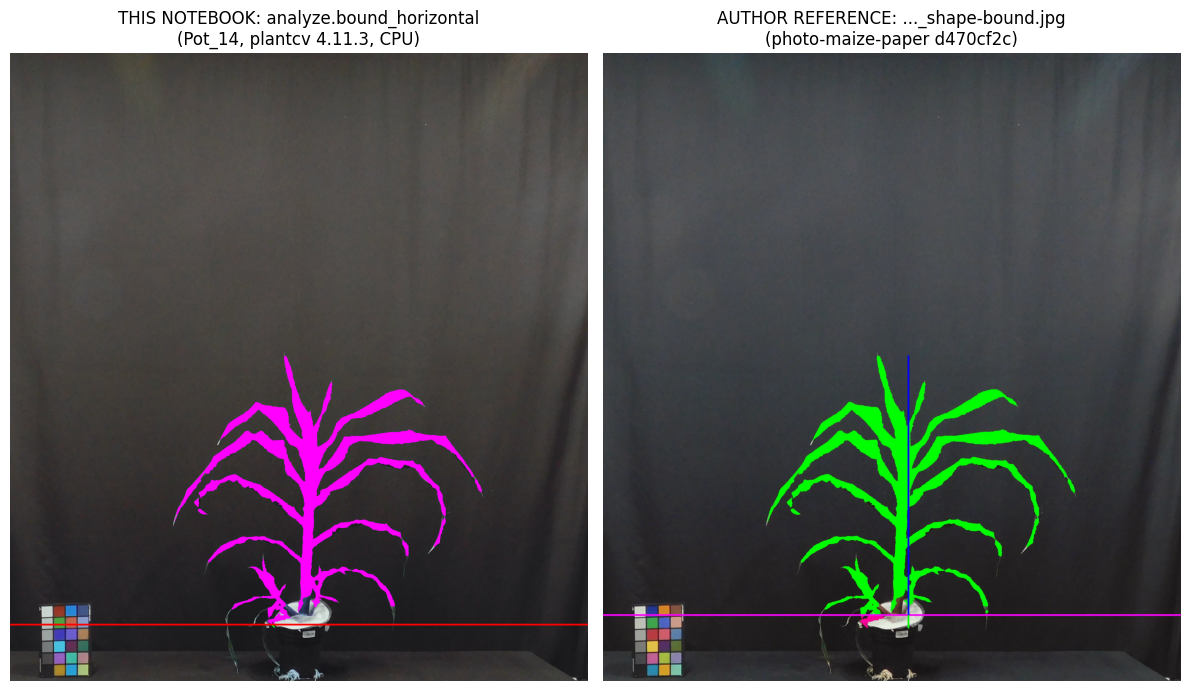

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
axes[0].imshow(shape_bound_image)
axes[0].set_title("THIS NOTEBOOK: analyze.bound_horizontal\n(Pot_14, plantcv 4.11.3, CPU)")
axes[1].imshow(cv2.cvtColor(ref_bound, cv2.COLOR_BGR2RGB))
axes[1].set_title("AUTHOR REFERENCE: ..._shape-bound.jpg\n(photo-maize-paper d470cf2c)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/content/outputs/12_comparison_bound.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Export

Export the notebook's trait table to CSV inside Colab (download it via the file browser
if desired). Values keep PlantCV's native units: pixel-based areas/lengths from the
cropped image and color statistics in 0–255 channel intensities.

*日本語: 形質表を Colab 内に CSV として保存します（単位は PlantCV 準拠：画素ベース）。*

In [ ]:
cmp_df.to_csv("/content/outputs/trait_comparison_Pot_14.csv", index=False)
single.to_csv("/content/outputs/notebook_traits_Pot_14.csv", index=False)
print(open("/content/outputs/trait_comparison_Pot_14.csv").read().splitlines()[0])
print("saved: /content/outputs/trait_comparison_Pot_14.csv, /content/outputs/notebook_traits_Pot_14.csv")

trait,author,notebook,abs_diff
saved: /content/outputs/trait_comparison_Pot_14.csv, /content/outputs/notebook_traits_Pot_14.csv


## 8. Interpretation and limitations

- What was reproduced: the authors' complete single-image photo-studio PlantCV pipeline
  (crop → color-card detection → affine color correction → Lab a/b dual threshold →
  fill/closing → ROI filter → size / bound-horizontal / color analyses) with the exact
  parameter values from `workflow.py` at pinned commit `d470cf2c`, on the authors' own
  sample image, compared against their saved outputs for the same image.
- Expected differences: PlantCV version (authors do not pin one; we used 4.11.3) and
  floating-point/rounding variation can cause small numeric differences — see the
  comparison table above. The segmentation thresholds were tuned by the authors for this
  imaging setup, so they must not be transferred to other cameras without re-checking.
- Not reproduced (out of scope): the camera/photo-studio protocol, batch processing of
  the full experiment, the >10-phenotype dataset-level tables and the R statistical
  analysis; the JoVE full text is subscription-gated, so stress-treatment parameters are
  not covered by this notebook.
- *日本語: 著者と同一のパラメータ・同一サンプルでのパイプライン再現と数値比較を行いました。
  差は PlantCV バージョン等に由来する小規模なものです。ハードウェア手順・バッチ処理・
  統計解析は対象外であり、JoVE 本文は購読限定のため扱っていません。*

**References**

1. Feldmann, M. J. et al. *Imaging and Analysis for Quantifying Maize (Zea mays) Abiotic
   Stress Phenotypes.* J. Vis. Exp. (2025). DOI 10.3791/67619, PMID 40228008.
2. `danforthcenter/photo-maize-paper` @ `d470cf2c4e2f73cd187f5982751b94ba277fe4b1`
   (`plantcv-analysis/workflow.py`), retrieved 2026-10-09.
3. Zenodo record 13379801 (version 10.5281/zenodo.13379801), deposited 2024-08-27,
   `raw-images.zip` MD5 `994f839c0b6b7d662fc715a2e865711f`.
4. PlantCV: Gehan et al., *PlantCV v2*, PeerJ (2017); Falk et al., *PlantCV v3*, GigaScience (2021). MPL-2.0.